---
title: Social Finance
subtitle: Online appendix and notes
exports:
  - format: pdf
    template: springer
    output: exports/socfin_m.pdf
abstract: |
  Derivations and code for graphs.
---

This notebook contains code to replicate and simulate different parameterizations of the model framework presented in our paper.

**Abstract:**  We propose a framework for understanding how social investors' who seek to maximize a combination of private and social returns from investments in a portfolio of new and established microfinance institutions.  The model takes into account the endogeneity of loan contract terms and the capital structure of the financial institutions that may emerge to target groups of borrowers differentiated primarily by their levels of initial average net worth. We study how social investments might transform those patterns, and how social investors might target their limited resources to balance depth and breadth of outreach objectives. We build upon one of the workhorse models of modern corporate finance (Tirole, 2007) which features limited liability, multiple layers of moral hazard and costly monitoring to explain patterns of financial intermediation, and in our framework, the role and modes of social investment.  We pinpoint the role of the subsidies and guarantees implicit in social investors' equity and quasi-equity investments and the role they play in attracting private capital investors and sustaining productivity-enhancing financial intermediation that might otherwise not have taken place. 

# Introduction

... We tackle the logic and tensions inherent in social finance--the support, with philanthropic objectives, of nonprofits, social businesses like the Grameen Bank, and profit-maximizing businesses serving the poor. The principles behind the new world of philanthropy and social action have not been well-explored by economists. We develop a theory of "social finance" to parallel the modern theory of corporate finance... 


#### **Model Overview & Foundations**
We extend the delegated financial intermediation frameworks of Holmstrom and Tirole (1997) and Conning (1999) to examine how an intermediary's capital structure and monitoring intensity vary endogenously with the wealth profile of its target borrowers. 

Our framework is built upon a standard credit-rationing model featuring borrower moral hazard and limited liability. This is the "workhorse" model of Tirole’s (2006) *The Theory of Corporate Finance*. Risk-neutral entrepreneurs require a lump-sum investment $I$ to undertake a project. Lacking liquid wealth, they must borrow the entire amount. To align incentives under moral hazard, an optimal contract must reward project success and penalize failure. Lenders will ration out any borrower whose pledgeable wealth falls below a threshold minimum collateral requirement, $\underline A$. A standalone interactive visualization of this basic credit-rationing model is available [here](3-basicmodel.ipynb).

To expand credit access, local intermediaries can engage in active monitoring to directly lower the borrower's private benefit of shirking, thereby reducing the minimum collateral requirement. However, monitoring is costly and unobservable to outside investors. To align the intermediary's own incentives, the optimal contract requires the MFI to hold sufficient "skin in the game" by investing its own scarce equity capital alongside outside uninformed lenders.

**A Core Innovation:** We assume that local monitoring capacity is neighborhood-specific, and that neighborhoods are segregated by their residents' average wealth. This allows us to determine the endogenous optimal capital structure and monitoring intensity of different financial institutions based entirely on the asset profiles of the communities they serve.

### **The Players in the Economy**
There are up to four types of active agents in the model:
1.  **Households (Entrepreneurs):** Local residents who seek to borrow a lump-sum $I$ to fund a risky productive project.
2.  **Local Microfinance Intermediaries (MFIs):** Informed intermediaries who originate and monitor loans. They invest their own equity capital and may leverage outside funds. They may be driven by commercial or social missions.
3.  **Uninformed Investors (Depositors):** Outside commercial creditors who provide low-cost debt capital to the MFI but cannot monitor.
4.  **Social Investors:** Altruistic actors who strategically deploy subsidies, guarantees, or soft equity to expand credit access and leverage private capital.

#### **Empirical & Institutional Predictions**
Each neighborhood $j$ is characterized by the average pledgeable assets $A_j$ of its households. Depending on this asset level $A_j$, the model endogenously predicts four distinct credit regimes:
1.  **Excluded (Unbanked):** Poorer households ($A_j$ is very low) cannot attract any funding. Monitoring is too expensive relative to their pledgeable wealth.
2.  **Monitored, Non-Leveraged MFI:** Households borrow from an MFI funded entirely by its own scarce equity capital ($I = I^m$). Heavy monitoring is required, and no outside debt can be attracted.
3.  **Monitored, Leveraged MFI:** Intermediary capital is leveraged with lower-cost outside debt ($I = I^m + I^u$). The MFI retains a smaller, incentive-compatible equity stake $I^m$ per loan.
4.  **Unmonitored, Highly-Leveraged Bank:** Wealthier households obtain cheap, unmonitored loans ($m=0$) backed entirely by their own collateral, maximizing outside commercial leverage.


By closing the model, we can endogenously predict the economy-wide equilibrium rates of return, bank capital structures, interest rates, and loan contract terms across the entire wealth distribution.

### Model code

Many of the functions used to simulate and visualize the model below are written in a [socialfinance](socialfinance.py) python module in the src folder that we import here.

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact

# Path configuration to find local package
sys.path.append(os.path.abspath('..'))

# Autoreload settings useful while developing socialfinance.py library
%load_ext autoreload
%autoreload 2

# Matplotlib styling
plt.rcParams['figure.figsize'] = (7.5, 5.5) 
plt.rcParams['text.usetex'] = False

# Import core classes
from socialfinance.socialfinance import Bank


Failed to read module file 'C:\Users\jonat\miniforge3\Lib\re\_casefix.py' for module 're._casefix': UnicodeDecodeError
Traceback (most recent call last):
  File "C:\Users\jonat\miniforge3\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\jonat\miniforge3\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\jonat\miniforge3\Lib\importlib\__init__.py", line 126, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1204, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1176, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1140, in _find_and_load_unlocked
ModuleNotFoundError: No module named 'a

Failed to read module file 'C:\Users\jonat\miniforge3\Lib\shlex.py' for module 'shlex': UnicodeDecodeError
Traceback (most recent call last):
  File "C:\Users\jonat\miniforge3\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\jonat\miniforge3\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\jonat\miniforge3\Lib\importlib\__init__.py", line 126, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1204, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1176, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1140, in _find_and_load_unlocked
ModuleNotFoundError: No module named 'autoreload'



Failed to read module file 'C:\Users\jonat\miniforge3\Lib\urllib\parse.py' for module 'urllib.parse': UnicodeDecodeError
Traceback (most recent call last):
  File "C:\Users\jonat\miniforge3\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\jonat\miniforge3\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\jonat\miniforge3\Lib\importlib\__init__.py", line 126, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1204, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1176, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1140, in _find_and_load_unlocked
ModuleNotFoundError: No module named 

Failed to read module file 'C:\Users\jonat\miniforge3\Lib\pydoc_data\topics.py' for module 'pydoc_data.topics': UnicodeDecodeError
Traceback (most recent call last):
  File "C:\Users\jonat\miniforge3\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\jonat\miniforge3\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\jonat\miniforge3\Lib\importlib\__init__.py", line 126, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1204, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1176, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1140, in _find_and_load_unlocked
ModuleNotFoundError: No mod

Failed to read module file 'C:\Users\jonat\miniforge3\Lib\functools.py' for module 'functools': UnicodeDecodeError
Traceback (most recent call last):
  File "C:\Users\jonat\miniforge3\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\jonat\miniforge3\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\jonat\miniforge3\Lib\importlib\__init__.py", line 126, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1204, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1176, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1140, in _find_and_load_unlocked
ModuleNotFoundError: No module named 'autor

We imagine a continuum of neighborhoods indexed by the level of pledgeable assets $A$ of its residents. We order these from low to high values. 
An `mfi` or microfinance institution serves the neighborhood.  Represented as a `Bank` object in the code.

In [2]:
A = np.linspace(0, 150, 500)   
mfi = Bank(A, beta = 1.2)


**Intermediary fixed cost per borrower**



#### **Borrower Moral Hazard & The Agency Problem**
Each risk-neutral household has access to a project requiring a lump-sum investment $I$. If they are **diligent** (exerting effort and utilizing funds properly), the project succeeds with probability $p$, yielding return $X_s$, and fails with probability $1-p$, yielding $X_f = 0$. 

If the entrepreneur is **non-diligent** (shirking or diverting resources), they capture a private benefit $B_0$, but the success probability falls to $q < p$. Because the entrepreneur's effort and private benefits are unobservable to the lender, a classic borrower moral hazard problem arises. 

To align incentives, a loan contract must be outcome-contingent. The contract is designed to maximize the borrower's expected return subject to the lender's break-even (participation) constraint.

For now, all borrowers are homogenous which means that every household in the neighborhood will have the same loan demand. In a [model extension](5-endogenous-NK.ipynb) we will allow for heterogeneity in borrower characteristics, which will make loan demand slope down with the cost of borrowing.

---

#### **Active Monitoring & Delegated Governance**
Lenders can mitigate this agency friction by acting as **active monitors** (e.g., a local MFI). By spending $m$ on monitoring and oversight (e.g., site visits, training, or audits), the MFI reduces the borrower's private shirk benefit:

$$
B(m) = B_0 - \alpha \cdot m
$$
where $\alpha > 0$ represents the **monitoring efficiency** parameter. 

*However, monitoring is itself costly and unobservable.* If the MFI leverages outside commercial funds to expand, a **second layer of moral hazard** emerges: outside investors must ensure that the MFI's managers have sufficient "skin in the game" to monitor diligently.

We assume a linear monitoring cost here to keep the results tractable, though we could also model monitoring with a non-linear cost function (for example, initially falling and then rising marginal cost).


#### **Neighborhoods & Capital Markets**

There are $J$ segregated neighborhoods. To get started, assume residents in neighborhood $j$ hold identical pledgeable assets $A_j$
$$A_j = j \cdot \frac{A^{max}}{J} \quad \text{for } j \in [0, J]$$

* **Loan Demand:** Each of the $N$ residents per neighborhood has access to the investment project requiring $I$. Total potential loan demand is $\bar{K} = N \cdot J \cdot I$.
* **Funding & Intermediation:** Local MFI monitoring capital $K$ is scarce. To expand, MFIs must leverage unlimited outside uninformed debt at a gross market cost of $\gamma$. We later analyze how scarce intermediary capital is allocated in equilibrium when aggregate demand exceeds supply.

### Microfinance Lending Contracts

A diligent borrower-entrepreneur's project generates a return $X_s$ with probability $p$ and a return $X_f$ with probability $1-p$.   A financial contract divides the project returns $X_i$ between returns to the monitoring intermediary $R_i$, returns to the entrepreneur $s_i$, and the uninformed lender gets what's left or $X_i-s_i-R_i$.  



#### **Baseline: Zero-Monitoring Loan ($m=0$)**

If a lender does not, or cannot, monitor then a feasible contract must satisfy two key constraints:

1. **Borrower Incentive Compatibility (IC):** To induce diligence, the success payout $s_s$ must exceed the failure payout $s_f$:
   $$s_s \ge s_f + \frac{B(0)}{p-q}$$
2. **Borrower Limited Liability (LL):** The borrower cannot pledge to pay more than their pledgeable collateral $A$:
   $$s_f \ge -A$$

Combining both binding constraints yields the borrower's **minimum expected economic rent**:
$$E(s|p) = -A + \frac{p \cdot B(0)}{p-q}$$

Notice that entrepreneurs with lower levels of pledgeable assets $A$ must earn higher expected rents to maintain incentives and satisfy limited liability.  Intuitively, since limited liability limits how much they can be punished for failure outcomes, the only way to maintain incentives is by offering rewards.  This requires keeping the return to the entrepreneur high enough in the success states, to give them an incentive to remain diligent.  But this is costly to the lender, since they can now not demand very much repayment in the success state or in the failure state. 

The microfinance lender must be able to cover this rent and her opportunity cost of funds $\beta I$ and fixed costs per loan $f$. 

**Fixed costs:** such as staff salaries, travel, and local setup expenses—are upfront operational costs that are entirely sunk and cannot be liquidated or recovered by depositors in the event of a default. We think of these as unrecoverable costs that must be financed out of own equity capital, whether the MFI is leveraged or not. Funding $f$ from scarce equity (at opportunity cost β) aligns with corporate finance reality and acts as a natural skin-in-the-game buffer, limiting the MFI's maximum leverage to $I/f$.


The lender is just able to break even and be willing to participate when:

$$
E(x|p) - E(s|p) = \beta \cdot I + \beta \cdot f
$$

$$
E(x|p)  + A  - p\frac{B(0)}{p-q} = \beta \cdot I + \beta \cdot f
$$

Solving for the $A$ as a function of $m$ where this exactly holds gives us the **minimum collateral requirement for an equity-only local MFI** who has opportunity cost of funds $\beta$ but sets monitoring intensity to zero.  We label this $A^e(0)$. The superscript $e$ refers to the fact that the MFI is lending exclusively from its own equity capital.  


$$
\underline A^e(0) = \frac{p \cdot B(0)}{p-q} 
 - \left[ {pX - \beta I - \beta f} \right]
$$

If a borrower has pledgeable assets $A$ in excess of this minimum collateral requirement then they'll pledge $\underline A^e(0)$ and borrow $I$ at cost $\beta I + \beta f$  

Entrepreneurs with $A \lt \underline A^e(0)$ will have to turn to more expensive monitored loans which we will analyze next.

We will later contrast this to a leveraged MFI that can leverage outside capital at a lower rate $\gamma<\beta$.  The intermediary may have to put some of their own capital at risk, but the end result is that they will be able to lend at a rate lower than $\beta$ but larger or equal to $\gamma$.

In [3]:
print(f'For our example, the minimum collateral requirement is A^e(0) = {mfi.AMe(0):.1f}')


For our example, the minimum collateral requirement is A^e(0) = 144.0


This is an example of an `over-collateralized' loan.  The bank is asking for \$140 security for a \$100 loan. Many asset poor borrowers will not have this level of pledgeable assets.  These people would be excluded from these loans but may have access to more expensive monitored loans as we analyze next.

We will next explore three strategies for reducing the minimium collateral requirement for loans: 1) by increasing the monitoring intensity my the MFI, 2) by using the MFI as an intermediary who is able to leverage lower cost funds from outside commercial investors; and 3) by introducing social investors who may provide subsidies to the MFI organization or their cost of funds.

#### Minimum collateral for a monitoring lender
A monitoring intermediary has the advantage of being able to monitor to directly lower the scope for moral hazard via $B(m)$ but they charge a higher cost of funds because (a) they face a higher opportunity cost of funds $\beta > \gamma$ and because (b) they must also be compensated for the cost of monitoring $m$.

Monitoring lowers the private benefit from non-diligence:

$$
E(s|p)= -A + p\frac{B(m)}{p-q}
$$

but monitoring adds a cost that must now be paid for:

$$
E(x|p) - E(s|p) = \beta \cdot I + m + \beta f
$$

The expression below shows how monitoring intensity $m$ can lower the collateral requirement for a monitoring intermediary when they are the only lender:

**Non-leveraged or Equity-only MFI**

$$
\underline A^e(m) = \frac{p \cdot B(m)}{p-q} - \left[ {pX - \beta I} \right]  + m + \beta f 
$$
 
Note that as monitoring $m$ must be paid for out of available project surplus, which reduces what is left to the entrepreneur after making all necessary repayments. Competition in a competitive market will lead to contracts with the minimum required monitoring, to keep costs to the borrower down.   That is they'll choose a monitoring intensity $m=m(A)$ that brings the monitoring minimum collateral requirement down to match the borrower's available pledgeable assets $A$ and make the loan feasible:

$$\underline A^e(m(A)) = A$$



Minimum Collateral Thresholds:
  Exclusion limit (Amin)            = 32.3333
  Leverage Crossover (Across)       = 94.9756
  Direct Credit Limit (AM(0))       = 124.0000
  Equity-only Direct Limit (AMe(0)) = 144.0000


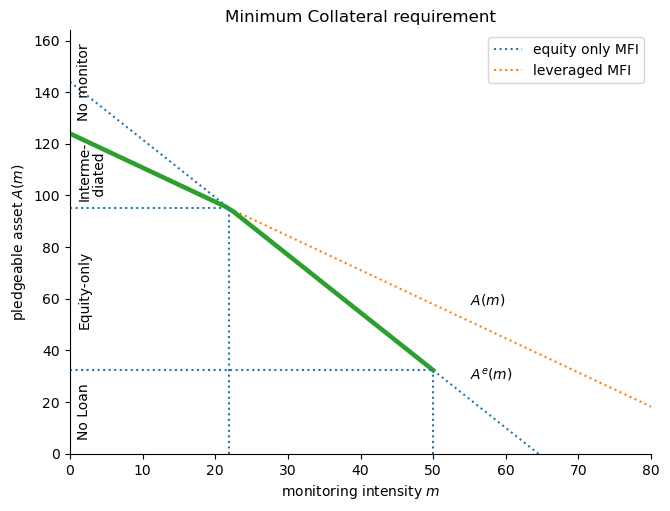

In [4]:
#| label: fig-A

mfi.plotA() 
plt.savefig('figs/fig-Am.png')

print(f"Minimum Collateral Thresholds:")
print(f"  Exclusion limit (Amin)            = {mfi.Amin():.4f}")
print(f"  Leverage Crossover (Across)       = {mfi.Across():.4f}")
print(f"  Direct Credit Limit (AM(0))       = {mfi.AM(0):.4f}")
print(f"  Equity-only Direct Limit (AMe(0)) = {mfi.AMe(0):.4f}")


:::{figure} figs/fig-Am.png
:name: fig-Am
:alt: Monitoring and collateral requirement
:width: 100%
:align: center

Monitoring intensity lowers the minimum collateral requirement for a loan. Pledgeable asset $A$ determines lowest cost loan.
:::

**Leveraged MFI**

If the local intermediary MFI can leverage outside capital it can potentially substitute cheaper outside financing for more expensive local intermediary (equity) financing. 

An outside lender will however only participate in a financing structure if it can be sure the monitoring intermediary has enough 'skin in the game' to have incentives to carry out the unobservable monitoring on the loan at this minimum intensity required for expected repayments to cover the uninformed lender's costs.  

A contract allocates claims as $s_i$ to the entrepreneur, $R_i$ to the monitoring lender and $X_i -R_i - s_i$ to the uninformed lender where $i = S, F$.  The monitor's incentive compatibility constraint requires that they earn more from being diligent in monitoring at expense $m$ than from not monitoring:

$$R_s \ge R_f + \frac{m}{p-q} $$

The lowest cost way to satisfy the monitor's incentive constraint (to have it bind) implies leaving a monitoring rent of:

$$
E(R|p) = R_f + p \cdot \frac{m}{p-q}
$$ 

to the intermediary.  This is analogous to the limited liability rent to the borrower.  

**Scarce Intermediary Capital**

Suppose there is only on intermediary in the neighborhood. Then they will put nothing at risk ($R_f=0$) and earn an economic rent of

$$
p \frac{m}{\Delta p}
$$

Now the 


$$
\underline A^M(m) = \frac{p \cdot B(m)}{p-q} - \left[ {pX - \beta I - \beta f} \right]  +  p \frac{m}{p-q}
$$







**Competition for intermediary services**

Assume instead now there is free entry into intermediation services. in the neighborhood. Intermediaries will now compete to lend to borrowers and leverage outside funds from uninformed lenders by putting up capital of their own.  This is "skin in the game" but it also reduces the rent.  

 Competition will insure that the untermediary earns zero profits (alternatively, we could assume intermediaries have a social mission to reach as many entrepreneurs as possible, and earn zero profits).  If the intermediary puts up $I^m$ of each $I$ loan and takes first losses then they stand to capture $R_f = -\beta I^m$ if the project fails and $R_s = -\beta I^m + \frac{m}{p-q}$ if the project succeeds.  Competition drives intermediary profits down to zero.  The expected returns from the contract (left hand side below) must cover the cost of monitoring $m$ plus the fixed cost per borrower:

$$p \cdot \frac{m}{p-q}  \ge \beta I^m +  m 

We can use this to find the size of the stake (or skin in the game) $I^m$ the monitoring intermediary must have in the project in order to have incentive to monitor:

$$
I^m = \frac{1}{\beta}\frac{q \cdot m}{p-q} 
$$

which is rising with the required amount of monitoring $m$ (to be determined).

The uninformed lender puts up $I^u = I - I^m$, and the monitor/MFI funds the required incentive equity $I^m$ plus the fixed administrative cost $f$ out of equity (totaling $I^m + f$).  The 'poorest' entrepreneur (i.e. the one with the lowest level of pledgeable assets A that can be reached) will be determined by the contract where what is left of expected project returns after paying the borrower the limited liability rent (required to make sure they choose the high probability of success project) is just enough to pay off both the uniformed and the informed lenders:


$$
E[X|p] - E[s|p] \ge \gamma (I - I_m) + \beta f + p \frac{m}{p-q}
$$


rearranging and using our earlier finding that $\beta I^m + m = p \frac{m}{p-q}$ we can solve for the minimum collateral requirement for the leveraged MFI:

$$
pX + A - p\frac{B(m)}{p-q} = \gamma (I - I^m) + \beta I^m + \beta f + m
$$




$$
\underline A (m) = p \cdot \frac{B(m)}{p-q} 
- \left[ {pX - \gamma I} \right] 
+ \frac{\beta - \gamma}{\beta} \left( \frac{q \cdot m}{p-q} \right ) + m + \beta f
$$

If $\beta=\gamma$ this collapses to the no-leverage minimum collateral requirement above. If $\beta \gt \gamma$, the premium paid for scarce intermediary capital adds to the cost.

### Financing Fixed Costs and Borrower-Specific WACC
Fixed operational costs ($f$) typically enter as an unscaled constant. However, since MFI financing combines equity $I^m$ (cost $\beta$) and debt (cost $\gamma$), we can define a borrower-specific Weighted Average Cost of Capital (WACC):
$$WACC_i = \gamma + (\beta - \gamma) w_e^i, \quad \text{where } w_e^i = \frac{I^m}{I + F}$$
Applying this to the MFI's total assets per loan ($I + f$) yields the total financing cost: $\gamma(I + f) + (\beta - \gamma)I^m$. Since the required MFI equity stake $I^m = \frac{q m}{\beta \Delta}$ is determined strictly by incentive compatibility, any marginal operational fixed cost is financed by debt. The total cost simplifies to $\gamma I + (\beta - \gamma)I^m + \beta f$. Thus, operational costs are priced at the cost of debt, $+ \beta f$.

**Financing Nuances:**
- **Tangible Fixed Assets (Debt-Financed):** If fixed costs consist of tangible, recoverable assets (e.g., equipment or vehicles) that depositors can recover in default, they are financed at the debt rate $\gamma$, yielding $+ \beta f$ in the formula. This preserves tractability in the simulations.
- **Sunk Operational Costs (Equity-Financed):** If the MFI operates in a debt-starved environment or if fixed costs are sunk (e.g., staff training or local setup), they must be funded out of scarce equity. Here, the fixed cost carries the equity premium, scaling to $+ \beta f$, which restricts MFI entry.


## Optimal (minimum required) monitoring

Monitoring is costly so only so much will be used as needed to lower the minimum collateral requirement to the entrepreneur's pledgeable asset level $A$> 

The minimum collateral requirement above can be rewritten as a function where higher monitoring $m$ reduces the collateral requirement from the no-monitoring collateral level. Using the fact that $B(m) = B(0) - \alpha m$ we can write the minimum collateral requirement as a function of monitoring intensity $m$ as:

$$\underline A (m) = \underline A (0) 
  - m \left [ p \cdot \frac{\alpha}{p-q} - \frac{(\beta - \gamma)}{\beta} \left( \frac{q}{p-q} \right ) -1 \right ]$$

If the entrepreneus can only access an equity-only lender (i.e. $I^m=I$):

$$\underline A^e(m) = A$$

where $\underline A^e(m) =  p \cdot \frac{B(m)}{p-q} - \left[ {pX - \beta I} 
    \right] + m + \beta f$



Solve for $m$ to get:

$$m^e(A) = \left[ \underline A^e(0)  - A \right] \cdot
    \frac{(p-q)}{ p(\alpha-1)+ q}$$
    


In this competitive setting the lender(s) earns zero profits. But the borrower will only participate if they can expect a positive return (borrower participation constraint). This determines the maximum feasible level of monitoring.  

$$
p \cdot X - \beta \cdot (I + f) - m \ge 0
$$



The two lines cross at $\underbar A(m, \beta) = AME(m, $\beta$) or at:

$$\bar m =  \frac{\beta(I+f)(p-q)}{q}$$



At zero monitoring it's obviously cheaper to use uninformed capital which has lower cost $\gamma$ rather than borrow from an local intermediary capital which has opportunity cost $\beta$.  Since the latter type of loans are more expensive, they'll also be associated with higher minimum collateral requirements.  Suppose $\beta = 1.2 \cdot \gamma$, then:

In [5]:
mfi.print_params()

Amax = 140, B0 = 30, F = 0, I = 100, K = 10000, X = 200
alpha = 0.5, beta = 1.2, f = 20, gamma = 1.0, p = 0.97, q = 0.82


In [6]:
mfi.beta = 1.2
print('Ame(0) = {:5.1f}  Am(0) = {:5.1f} '.format(mfi.AMe(0), mfi.AM(0)))


Ame(0) = 144.0  Am(0) = 124.0 


In [7]:
mfi.mmax()

50.0

(NOTE the following expression assume $f = 0$)
For any entrepreneur with pledgeable assets $A$ we can find optimal (minimum) amount of monitoring):

$$\underline A^e(m) = A$$
solve for $m$ to get:
 


$$m(A) = \left[ \underline A^e(0)  - A \right] \cdot
    \frac{(p-q)}{ p(\alpha-1)+ q}$$
    


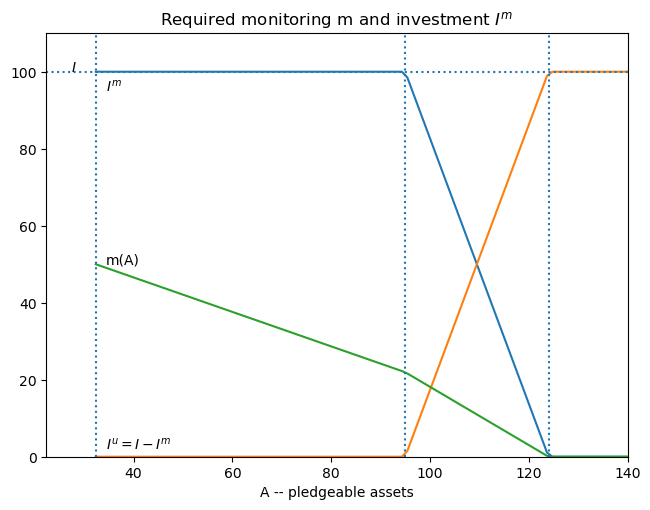

In [8]:
#| label: fig-rmonitoring
mfi.plotIm()

In [9]:
mfi.AM(0), mfi.AM(0)

(123.99999999999997, 123.99999999999997)

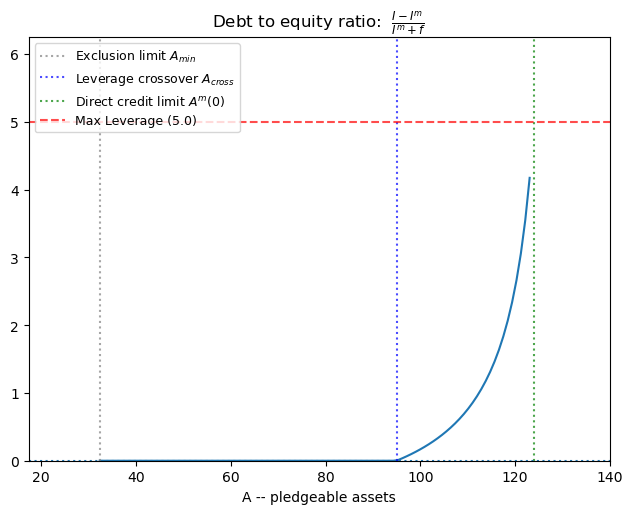

In [10]:
mfi.beta = 1.2
mfi.plotDE(mfi.beta)


## The borrower/entrepreneur's expected return

Is what is left after all others have been paid. 

If it is an equity only loan then the expected return is:

$$E(s|p) = pX - \beta \cdot I  - \beta f  - m^e(A)$$



If it's a leveraged loan then the expected return is:

$$E(s|p) = pX - \gamma \cdot I  - \beta f  - m(A) \left ( 
  1 + \frac{\beta-\gamma}{\beta} \frac{q}{p-q} 
 \right )  $$

## MFI Outreach and Borrower Returns across the Asset Distribution

To understand how borrower wealth affects credit access and MFI scale, we look at the MFI's capacity to serve a neighborhood of identical borrowers with asset level $A$.

Very importantly:  we wassume a fixed amount of equity capital $K$ in each neighborhood.  In a later notebook we will allow $K$ to move and vary by neighborhood.


### Neighborhood Capital & Leverage Assumptions

For any given neighborhood where residents have identical pledgeable assets $A$:
1. **The MFI Capacity/Outreach ($N(A)$):** We assume the MFI has a fixed pool of startup/intermediary equity capital $K = 10,000$ (with setup costs $F=0$ here). 
2. **Leverage and Monitoring Equity ($I^m(A)$):**
   * **Unmonitored Region ($A > A^m(0)$):** Borrowers are wealthy enough that they need no monitoring. They get funded directly by commercial lenders; the MFI plays no role.
   * **Leveraged Region ($A^m(0) \ge A > A_{cross}$):** Borrowers need some monitoring, but can attract outside debt. The MFI must put up a monitoring equity stake $I^m(A) < I$ per loan to be incentive-compatible. By leveraging outside funds, the MFI can reach a larger number of borrowers: $N(A) = K/(I^m(A) + f)$. As $A$ decreases, the needed monitoring $m$ increases, requiring more MFI equity $I^m$ per loan, which compresses MFI leverage and reduces $N(A)$.
   * **Equity-Only Region ($A_{cross} \ge A \ge A_{min}$):** Borrowers need heavy monitoring. No outside investor will fund them, so the MFI must fund them using 100% equity ($I^m(A) = I$). The MFI's reach is capped at its raw equity capacity: $N(A) = K/(I+f) \approx 83.3$ loans.


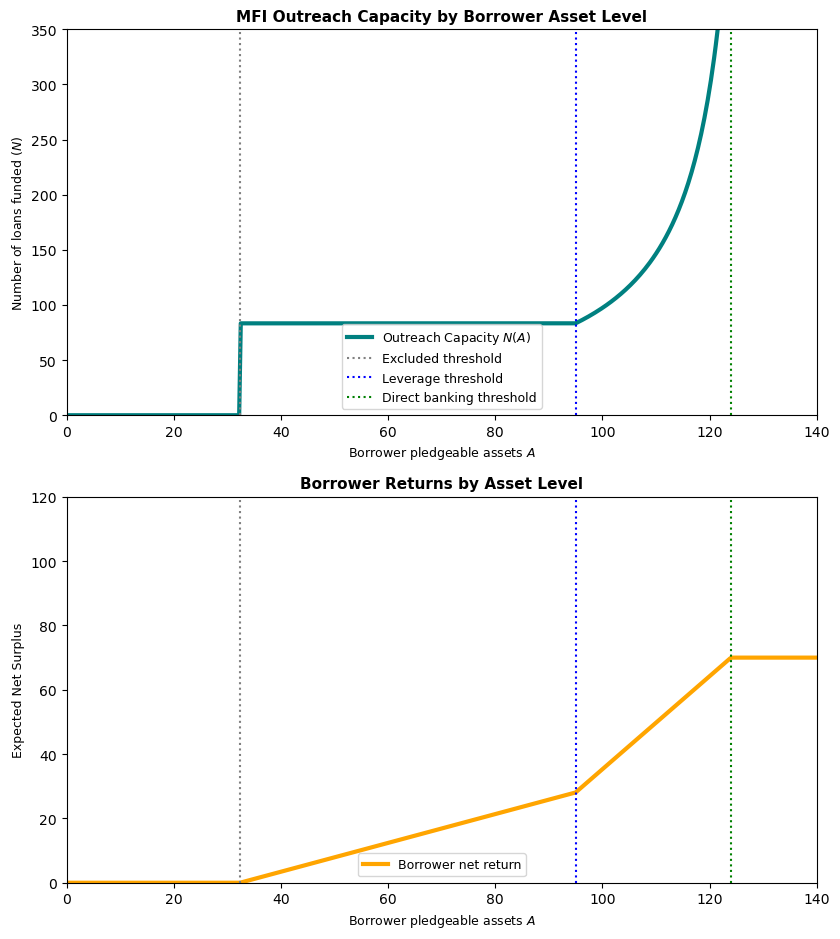

In [11]:
# Initialize the MFI's capacity parameter
mfi.K = 10000.0  # MFI startup capital parameter

# Calculate borrower capacity outreach N(A) and net returns
nr = mfi.nreach(A)
br = mfi.breturn(A)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8.5, 9.5))

# Plot 1: Outreach Capacity
ax1.plot(A, nr, color='teal', linewidth=3, label='Outreach Capacity $N(A)$')
ax1.axvline(x=mfi.Amin(), linestyle=':', color='grey', label='Excluded threshold')
ax1.axvline(x=mfi.Across(), linestyle=':', color='blue', label='Leverage threshold')
ax1.axvline(x=mfi.AM(0), linestyle=':', color='green', label='Direct banking threshold')
ax1.set_title("MFI Outreach Capacity by Borrower Asset Level", fontsize=11, weight='bold')
ax1.set_xlabel("Borrower pledgeable assets $A$", fontsize=9)
ax1.set_ylabel("Number of loans funded ($N$)", fontsize=9)
ax1.set_xlim(0, 140)
ax1.set_ylim(0, 350)
ax1.legend(fontsize=9)

# Plot 2: Borrower returns
ax2.plot(A, br, color='orange', linewidth=3, label='Borrower net return')
ax2.axvline(x=mfi.Amin(), linestyle=':', color='grey')
ax2.axvline(x=mfi.Across(), linestyle=':', color='blue')
ax2.axvline(x=mfi.AM(0), linestyle=':', color='green')
ax2.set_title("Borrower Returns by Asset Level", fontsize=11, weight='bold')
ax2.set_xlabel("Borrower pledgeable assets $A$", fontsize=9)
ax2.set_ylabel("Expected Net Surplus", fontsize=9)
ax2.set_xlim(0, 140)
ax2.set_ylim(0, 120)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('figs/fig-credit-landscape.png', dpi=300)
plt.show()

## The effect of subsidizing fixed costs

There are four groups distinguished by the type of borrowing they can access:

|Group  | Definition    |
| ------------- |-------------|
| 1             | no access to lending |
| 2             | equity-only MFI  | 
| 3             | leveraged MFI   |   
| 4             | direct banking    |  


Let us look at the effect of a fixed cost subsidy (reduce f = 20 to f = 10) on borrower returns.




| Impact Group | Definition   | notes   |
|------        |------        |-----    |
|  A  | Group 1 --> Group 2 |  new MFI emerges where none before |
|  B  | Group 2 --> Group 2 |  support existing MFIs , but no new leverage |
|  C  | Group 2 --> Group 3 |  transforms equity-only to leveraged MFI |
|  D  | Group 3 --> Group 3 or 4 |  increase leverage at already leveraged |





Let us look at the effect of a fixed cost subsidy (reduce f = 20 to f = 10) on borrower returns.


In [12]:
br1 = mfi.breturn(A)       # borrower return in MFIs with f=20
mfi2 = Bank(A, mfi.beta)             
mfi2.f = mfi.f - 10
br2 = mfi2.breturn(A)     # borrower return in MFIs with f=10


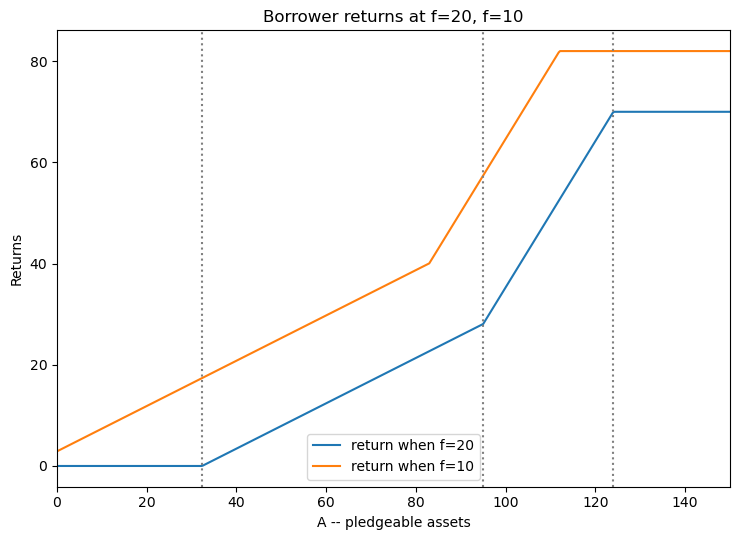

In [13]:
#| label: fig-brcompare
plt.plot(A, br1, label=f'return when f={mfi.f}')
plt.plot(A, br2, label=f'return when f={mfi2.f}')
plt.title('Borrower returns at f=20, f=10')
plt.xlabel('A -- pledgeable assets')
plt.ylabel('Returns')
plt.axvline(x=mfi.Amin(), linestyle=':', color='grey')
plt.axvline(x=mfi.Across(), linestyle=':', color='grey')
plt.axvline(x=mfi.AM(0), linestyle=':', color='grey')
plt.legend()
plt.tight_layout()
plt.xlim(0, max(A));


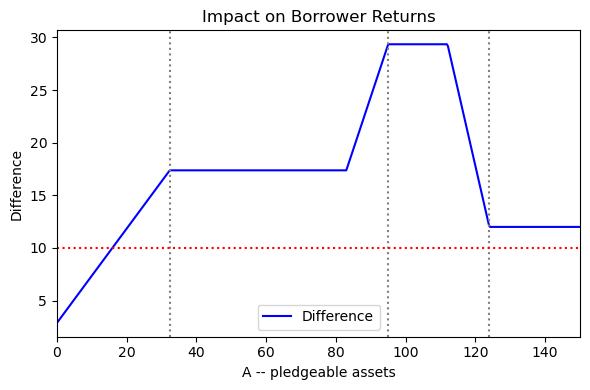

In [14]:
#| label: fig-brdiff
plt.figure(figsize=(6, 4))
plt.plot(A, br2-br1, label='Difference', color='blue')
plt.title('Impact on Borrower Returns')
plt.xlabel('A -- pledgeable assets')
plt.ylabel('Difference')
plt.axvline(x=mfi.Amin(), linestyle=':', color='grey')
plt.axvline(x=mfi.Across(), linestyle=':', color='grey')
plt.axvline(x=mfi.AM(0), linestyle=':', color='grey')
plt.axhline(y=mfi.f-mfi2.f, linestyle=':', color='red')  # dashed line at subsidy level (20=20-10)
plt.legend()
plt.tight_layout()
plt.xlim(0, max(A));




**Analysis:**  

| Impact Group | description   | notes |
|------        |------        |-----    |
|  A  | previously excluded borrowers | only those with higher A get benefits > subsidy |
|  B  | existing no-leverage borrowers | benefit>subsidy|
|  C  | borrowers in transformed MFI |  leverage gives extra kick to subsidy, increasing with A |
|  D  | leveraged to direct borrowing|  impact greater than subsidy but declining with A|
|  E  | Group 4 --> Group 4 |  subsidy passed through 1 for 1 |


### Subsidy impact on number of borrowers:

We are looking at fixed-cost per loan $f$.  

$$
N = \frac{K}{I^m + f}


(0.0, 500.0)

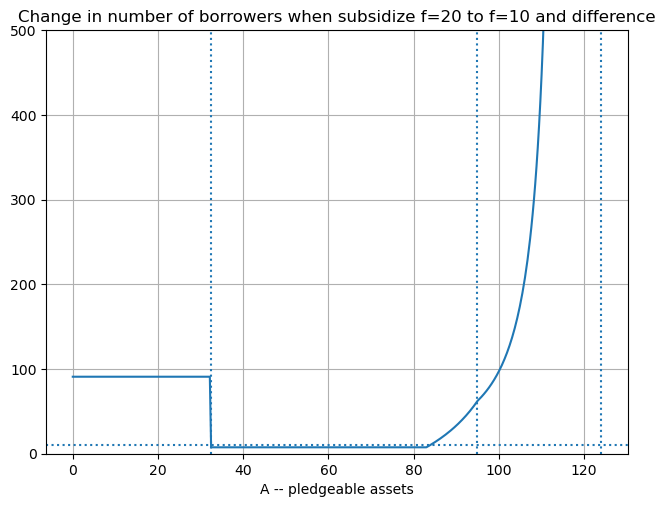

In [15]:
nr1 = mfi.nreach(A)       #number borrowers in MFIs with f=20
nr2 = mfi2.nreach(A)      #number borrowers in MFIs with f=10

#plt.plot(A,nr1)
#plt.plot(A,nr2)
plt.plot(A, nr2-nr1)                   # change in borrower return
plt.title('Change in number of borrowers when subsidize f=20 to f=10 and difference')
plt.xlabel('A -- pledgeable assets')
plt.axvline(x=mfi.Amin(), linestyle =':')
plt.axvline(x=mfi.Across(), linestyle =':')
plt.axvline(x=mfi.AM(0), linestyle =':')
plt.axhline(y=mfi.f-mfi2.f,linestyle=':');     # dashed line at subsidy level (20-10)
plt.grid()
plt.ylim(0, 500)


Interpretations:
- 1.  Subsidy to fixed costs will bring new MFIs into the market on the lower end, increasing the number of borrowers served.  This is the A impact group.
- 2.  Subsidy to fixed costs will increase the number of borrowers served by existing MFIs, but not bring new MFIs into the market.  This is the B impact group.


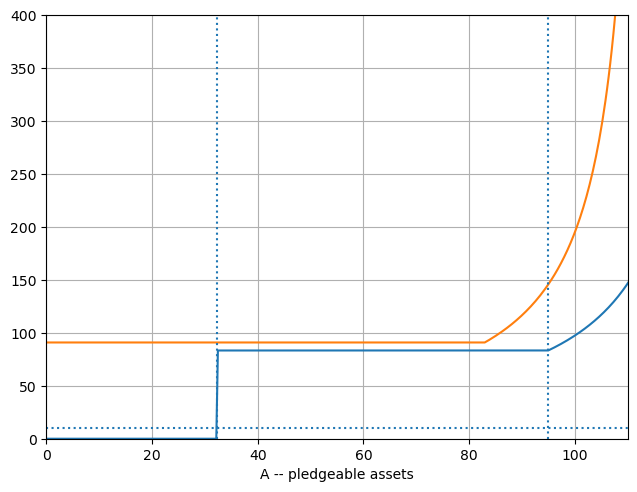

In [16]:
plt.plot(A,nr1)
plt.plot(A,nr2)
#plt.plot(A,nr2)
plt.xlabel('A -- pledgeable assets')
plt.xlim(0,110), plt.ylim(0,400)
plt.axvline(x=mfi.Amin(), linestyle =':')
plt.axvline(x=mfi.Across(), linestyle =':')
plt.axvline(x=mfi.AM(0), linestyle =':')
plt.axhline(y=mfi.f-mfi2.f,linestyle=':');     # dashed line at subsidy level (20-10)
plt.grid()


In [17]:
mfi2.K

10000

Analysis:  Recall that K = 10000.  So a non-leveraged lender can reach $N = 10000/(100+f)$.  When $f=20$ they can reach 83.3 borrowers. When $f=10$ they can reach 90.9 borrowers. 

**Analysis:**  

| Impact Group | description   | notes |
|------        |------        |-----    |
|  A  | previously excluded borrowers | 90.9 new borrowers in each of these new MFIs |
|  B  | existing no-leverage borrowers | just 7.6 new borrowers per MFI |
|  C, D  | borrowers in transformed MFI |  increase leverage gets many new, increasing with A |




In [18]:
200*25

5000

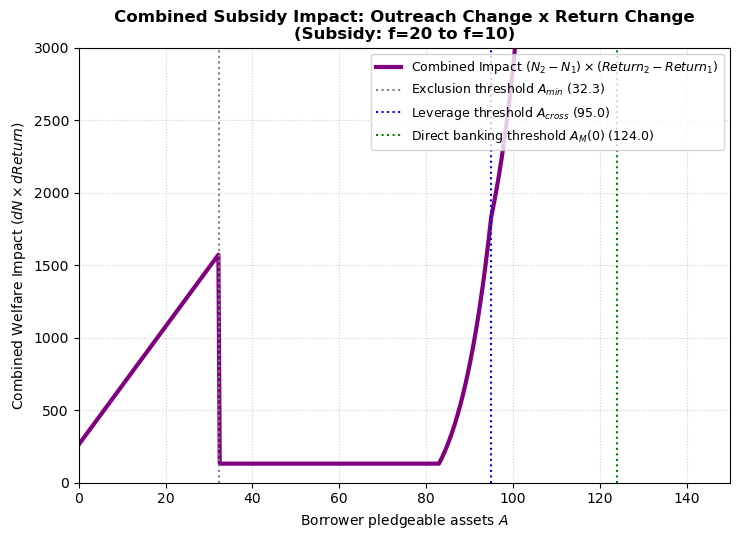

In [19]:
#| label: fig-combined-impact
prod = (nr2 - nr1) * (br2 - br1)

plt.figure(figsize=(7.5, 5.5))
plt.plot(A, prod, color='purple', linewidth=3, label=r'Combined Impact $(N_2 - N_1) \times (Return_2 - Return_1)$')

# Add threshold lines for baseline MFI
plt.axvline(x=mfi.Amin(), linestyle=':', color='grey', label=r'Exclusion threshold $A_{{min}}$ ({:.1f})'.format(mfi.Amin()))
plt.axvline(x=mfi.Across(), linestyle=':', color='blue', label=r'Leverage threshold $A_{{cross}}$ ({:.1f})'.format(mfi.Across()))
plt.axvline(x=mfi.AM(0), linestyle=':', color='green', label=r'Direct banking threshold $A_{{M}}(0)$ ({:.1f})'.format(mfi.AM(0)))

plt.title('Combined Subsidy Impact: Outreach Change x Return Change\n(Subsidy: f=20 to f=10)', fontsize=12, weight='bold')
plt.xlabel('Borrower pledgeable assets $A$', fontsize=10)
plt.ylabel(r'Combined Welfare Impact ($dN \times dReturn$)', fontsize=10)
plt.xlim(0, max(A))
plt.ylim(0, 3000)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=9, loc='upper right')
plt.tight_layout()

# Save the plot
import os
os.makedirs('figs', exist_ok=True)
plt.savefig('figs/fig-subsidy-combined.png', dpi=300)
plt.show()


# 3. The Commercial MFI: Selfish Equity & Leverage Rationing

In the preceding analysis, we assumed that microfinance intermediaries operate in a highly competitive or altruistic market, earning a rate of return on their informed equity capital $\beta$ exactly equal to the cost of uninformed debt capital $\gamma$ ($\beta = 1.2, \gamma = 1.0$). 

However, in many developing economies, **informed intermediary capital is highly scarce**. Managers and loan officers who possess the specialized skills to screen and monitor borrowers are rare. In a purely commercial landscape, these scarce equity investors will demand an expected rate of return on their equity capital in excess of the cost of debt ($\beta > \gamma$).

### The Impact of Commercial ROE Hurdles
When profit-maximizing equity investors demand a high rate of return $\beta > \gamma$:
1. **Wasteful Over-Monitoring:** To deliver the higher return to the monitor while maintaining borrower incentives, the offered contract shifts. Borrowers are subjected to more intensive active monitoring $m$ than they would choose in a competitive or social finance environment.
2. **Leverage Rationing:** From the monitor's incentive compatibility constraint:
   $$\beta \cdot I^m = \frac{q \cdot m}{p - q}$$
   As the hurdle rate $\beta$ rises, the MFI is forced to retain a **deeper equity stake** $I^m$ in each project to keep their monitoring incentives credible. This restricts their ability to leverage outside funds, reducing their debt-to-equity ratio and limiting their total borrower reach ($N$).


In [20]:
# Let's explore the effect of scarce commercial capital on our MFI
print("--- Baseline Social Finance vs. Commercial Hurdles ---")
print(f"Baseline Social Finance (beta = gamma = {mfi.beta:.1f}):")
print(f"  Crossing monitoring mcross = {mfi.mcross():.4f}")
print(f"  Crossing collateral Across = {mfi.Across():.4f}")
print(f"  Lowest collateral Amin = {mfi.Amin():.4f}")

# Loop through beta steps from 1.1 to 1.5
for b in [1.1, 1.2, 1.3, 1.4, 1.5]:
    mfi_temp = Bank(A, beta=b)
    print(f"\nCommercial MFI (beta = {b:.1f}):")
    print(f"  Crossing monitoring mcross = {mfi_temp.mcross():.4f}")
    print(f"  Crossing collateral Across = {mfi_temp.Across():.4f}")
    print(f"  Lowest collateral Amin = {mfi_temp.Amin():.4f}")


--- Baseline Social Finance vs. Commercial Hurdles ---
Baseline Social Finance (beta = gamma = 1.2):
  Crossing monitoring mcross = 21.9512
  Crossing collateral Across = 94.9756
  Lowest collateral Amin = 32.3333

Commercial MFI (beta = 1.1):
  Crossing monitoring mcross = 20.1220
  Crossing collateral Across = 87.0610
  Lowest collateral Amin = -6.4667

Commercial MFI (beta = 1.2):
  Crossing monitoring mcross = 21.9512
  Crossing collateral Across = 94.9756
  Lowest collateral Amin = 32.3333

Commercial MFI (beta = 1.3):
  Crossing monitoring mcross = 23.7805
  Crossing collateral Across = 102.8902
  Lowest collateral Amin = 71.1333

Commercial MFI (beta = 1.4):
  Crossing monitoring mcross = 25.6098
  Crossing collateral Across = 110.8049
  Lowest collateral Amin = 109.9333

Commercial MFI (beta = 1.5):
  Crossing monitoring mcross = 27.4390
  Crossing collateral Across = 118.7195
  Lowest collateral Amin = 148.7333


### Visualizing the Contract Frontier and Over-monitoring

The plot below demonstrates how shifting from a social investor ($\beta = 1.2$) to a commercial monitor ($\beta = 1.5$) raises the minimum collateral requirement curve $A(m)$ for the leveraged MFI. This pushes the crossing point $m_{cross}$ to the right, meaning that for any given asset level, commercial borrowers are subjected to significantly higher monitoring intensity (and therefore higher interest rates) than they would pay under a social lender.


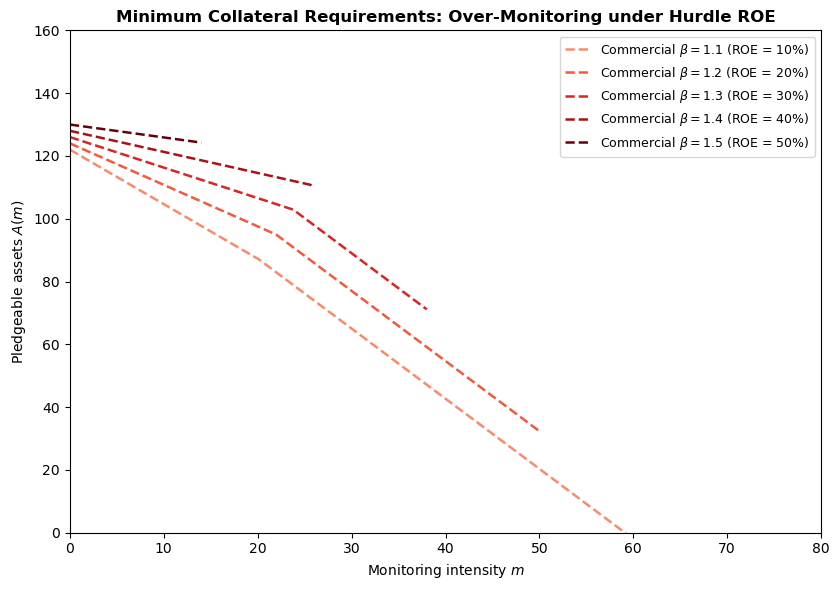

In [21]:
# Plot minimum collateral requirements comparing baseline and ROE steps
fig, ax = plt.subplots(figsize=(8.5, 6))
mm = np.linspace(0, 80, 500)


# Use a colormap to plot beta steps from 1.1 to 1.5
import matplotlib.cm as cm
betas = [1.1, 1.2, 1.3, 1.4, 1.5]
colors = cm.Reds(np.linspace(0.4, 1.0, len(betas)))

for b, color in zip(betas, colors):
    mfi_temp = Bank(A, beta=b)
    mmax_temp = mfi_temp.mmax()
    if mmax_temp > 0:
        mm_env = np.linspace(0, mmax_temp, 500)
        ax.plot(mm_env, mfi_temp.Abest(mm_env), linewidth=1.8, color=color, linestyle='--',
                label=rf'Commercial $\beta = {b:.1f}$ (ROE = {(b-1.0)*100:.0f}%)')

ax.set_title("Minimum Collateral Requirements: Over-Monitoring under Hurdle ROE", fontsize=12, weight='bold')
ax.set_xlabel("Monitoring intensity $m$", fontsize=10)
ax.set_ylabel("Pledgeable assets $A(m)$", fontsize=10)
ax.set_xlim(0, 80)
ax.set_ylim(0, 160)
ax.legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.savefig('figs/fig-commercial-AM.png', dpi=300)
plt.show()


### Leverage Rationing and Debt-to-Equity Collapsation

As $\beta$ grows, the required equity stake $I^m$ per loan must rise to satisfy the monitor's incentives. Consequently, the debt-to-equity ratio collapses. The plot below maps the debt-to-equity ratio $\frac{I - I^m}{I^m + f}$ across different pledgeable asset levels. Note how the commercial MFI's leverage curve (red) sits significantly below the social MFI's leverage curve (blue), demonstrating how commercial profit-maximizing hurdles restrict leverage and limit the scale of financial inclusion.

To prevent the leverage ratio from rising to infinity as required monitoring goes to zero for wealthy borrowers, we assume that the fixed administrative cost of operation $f$ must always be financed out of MFI equity (at opportunity cost $\beta$). The debt-to-equity ratio is therefore:
$$\text{D/E} = \frac{I - I^m(A)}{I^m(A) + f}$$
Since $I^m(A) \ge 0$, this naturally bounds the maximum leverage ratio at:
$$\text{Max D/E} = \frac{I}{f} = \frac{100}{20} = 5.0$$


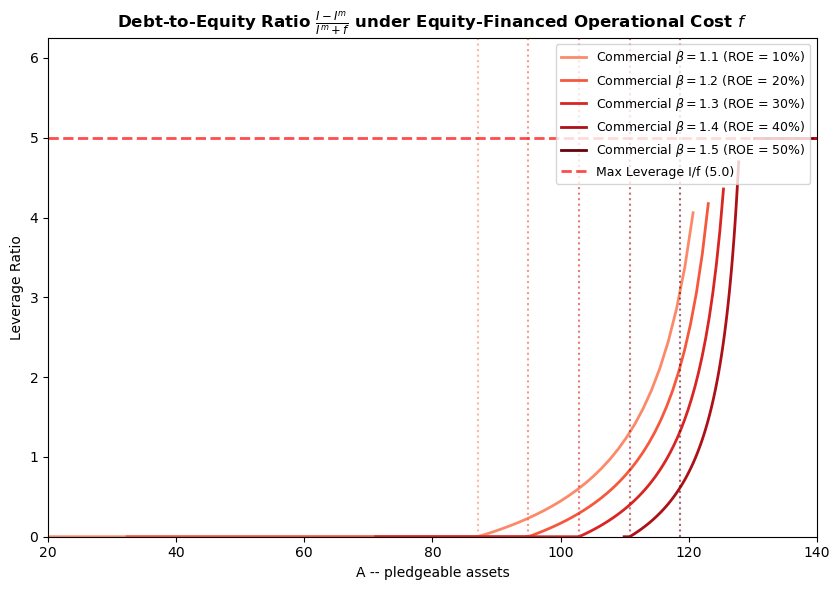

In [22]:
# Plot Debt-to-Equity ratios comparing baseline and ROE steps
fig, ax = plt.subplots(figsize=(8.5, 6))

# Baseline (beta = 1.2) - leverage is capped at I/f under equity-financed operational cost f
# Plot the leverage curves for beta steps from 1.1 to 1.5
import matplotlib.cm as cm
betas = [1.1, 1.2, 1.3, 1.4, 1.5]
colors = cm.Reds(np.linspace(0.4, 1.0, len(betas)))

for b, color in zip(betas, colors):
    mfi_temp = Bank(A, beta=b)
    amin_temp = mfi_temp.Amin()
    A_temp = np.linspace(amin_temp, mfi_temp.AM(0), 100)[:-1]
    Im_temp = np.array([mfi_temp.Im(m) for m in mfi_temp.minmon(A_temp)])
    de_temp = np.divide(mfi_temp.I - Im_temp, Im_temp + mfi_temp.f, out=np.zeros_like(Im_temp), where=(Im_temp + mfi_temp.f)>0)
    
    ax.plot(A_temp, de_temp, label=rf'Commercial $\beta = {b:.1f}$ (ROE = {(b-1.0)*100:.0f}%)', color=color, linewidth=2)
    ax.axvline(x=mfi_temp.Across(), linestyle=':', color=color, alpha=0.6)

# Draw the natural leverage limit line
max_de = mfi.I / mfi.f
ax.axhline(y=max_de, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Max Leverage I/f ({max_de:.1f})')

ax.set_title(r"Debt-to-Equity Ratio $\frac{I - I^m}{I^m + f}$ under Equity-Financed Operational Cost $f$", fontsize=12, weight='bold')
ax.set_xlabel("A -- pledgeable assets", fontsize=10)
ax.set_ylabel("Leverage Ratio", fontsize=10)
ax.set_xlim(20, 140)
ax.set_ylim(0, max_de * 1.25)  # dynamically sets y-limit to exactly 1.25 times the cap (12.5)
ax.legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.savefig('figs/fig-commercial-DE.png', dpi=300)


# 4. Interactive Contract Space Simulator

Use the interactive sliders below to dynamically explore the contract space! You can vary the cost of equity ($\beta$), the cost of uninformed debt ($\gamma$), and the monitoring slope ($\alpha$) to see in real time how:
* The minimum collateral boundaries $A^e(m)$ and $A(m)$ shift.
* The crossing point $m_{cross}$ and leverage boundaries adapt.


In [23]:
# Define the interactive simulator function
def simulate_contract_space(beta=1.2, gamma=1.0, alpha=0.5, f=20, B_0=30, q=0.82):
    # Close all previous matplotlib figures to prevent duplication/memory leaks
    import matplotlib.pyplot as plt
    plt.close('all')
    
    # Clear the previous cell output in the notebook
    from IPython.display import clear_output
    clear_output(wait=True)
    
    # Create a dynamic bank instance
    sim_mfi = Bank(A, beta=beta)
    sim_mfi.gamma = gamma
    sim_mfi.alpha = alpha
    sim_mfi.f = f
    sim_mfi.B0 = B_0
    sim_mfi.q = q
    
    mc = sim_mfi.mcross()
    Amc = sim_mfi.AM(mc)
    mmax_val = sim_mfi.mmax()
    
    fig, ax = plt.subplots(figsize=(8, 6))
    mm = np.linspace(0, 100, 500)
    
    # Plot baseline curves as thin dotted/dashed lines
    ax.plot(mm, sim_mfi.AMe(mm), label=r'Equity-only MFI $A^e(m)$', linestyle=':', color='green', alpha=0.4)
    ax.plot(mm, sim_mfi.AM(mm), label=r'Leveraged MFI $A(m)$', linestyle='--', color='purple', alpha=0.4)
    
    # Plot the thick solid envelope if feasible
    if mmax_val > 0:
        mm_env = np.linspace(0, mmax_val, 200)
        ax.plot(mm_env, sim_mfi.Abest(mm_env), linewidth=3.3, color='blue', label='Feasible Frontier')
        
        # Mark mmax
        Ammax = sim_mfi.Abest(mmax_val)
        ax.plot(mmax_val, Ammax, 'ro', markersize=8, label=f'Max Monitoring (m={mmax_val:.1f})')
        ax.vlines(mmax_val, ymin=0, ymax=Ammax, linestyle='--', color='red', alpha=0.6)
    else:
        ax.text(40, 80, "No Feasible Contract Space\n(Market Collapsed)", 
                color='red', fontsize=14, ha='center', va='center', weight='bold')
        
    # Add key crossings
    ax.plot(mc, Amc, 'go', markersize=8, label=f'Crossover Point (m={mc:.1f})')
    ax.vlines([mc], ymin=0, ymax=Amc, linestyle=':', color='green', alpha=0.6)
    
    # Format plot
    ax.set_title(rf"Dynamic Contract Space ($\beta={beta:.2f}$, $\gamma={gamma:.2f}$, $\alpha={alpha:.2f}$, $f={f:.0f}$, $B_0={B_0:.0f}$, $q={q:.2f}$)")
    ax.set_xlabel("Monitoring intensity $m$")
    ax.set_ylabel("Pledgeable assets $A(m)$")
    ax.set_xlim(0, 80)
    ax.set_ylim(0, 160)
    ax.legend(loc='upper right')
    ax.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

# Setup interactive dashboard
interact(simulate_contract_space, 
         beta=(1.0, 1.8, 0.05), 
         gamma=(1.0, 1.2, 0.05), 
         alpha=(0.1, 0.9, 0.05),
         f=(0, 30, 5),
         B_0=(15, 45, 5),
         q=(0.70, 0.95, 0.01));


interactive(children=(FloatSlider(value=1.2, description='beta', max=1.8, min=1.0, step=0.05), FloatSlider(val…